# External predictions, temporal backtesting, and feature shift

**Goal.** Align external predictions to point-in-time rows, evaluate matured labels, inspect temporal windows, and compute distribution shift. The notebook adds a real scikit-learn t-SNE view of the feature space.

**Audience.** Data/ML scientists, fraud analysts, platform engineers, and researchers.

**Prerequisites.** Python 3.12+, a clean checkout, and the base FraudTwin install. The workflow is deterministic and runs offline; service integrations are deliberately out of scope here.

**Source size.** 1,000–10,000 logical payments. Every section writes only compact summaries, manifests, or fingerprints to a temporary directory.

**Interpretation.** Synthetic evidence demonstrates mechanics and invariants, not production prevalence or model performance guarantees.

**Evaluation timing.** This notebook uses a three-day delayed batch prediction time so the configured delayed labels can mature. Real-time predictions should expect more unresolved labels.


## External predictions and temporal backtesting



In [1]:
from collections import Counter
from pathlib import Path

from fraudtwin.config import load_config
from fraudtwin.generation import generate
from fraudtwin.ml.baseline import PredictionRecord
from fraudtwin.reproducibility import sha256_json

root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs" / "minimal-v1.yaml").is_file()),
    Path.cwd(),
)
config = load_config(root / "configs" / "benchmarks" / "camouflage-v1.yaml")
evaluation_delay_seconds = 3 * 86_400
config = config.model_copy(
    update={
        "dataset": config.dataset.model_copy(
            update={"prediction_delay_seconds": evaluation_delay_seconds}
        )
    }
)
data = generate(config, write=False)
dataset = data.require_dataset()
rows = dataset.frame.to_dicts()
print("Source dataset")
print(f"  Run ID: {data.run_id}")
print(f"  point-in-time rows: {len(rows):,}")
print(f"  evaluation delay: {evaluation_delay_seconds // 86_400} days")
assert len(rows) > 500

Source dataset
  Run ID: RUN-3c8a07d6ac6d0773
  point-in-time rows: 612
  evaluation delay: 3 days


In [2]:
predictions = [
    PredictionRecord(
        event_id=r["event_id"],
        prediction_timestamp=r["prediction_time"],
        fraud_score=min(1.0, float(r["amount"]) / 5000.0),
    )
    for r in rows
]
print("Predictions")
print(f"  records: {len(predictions):,}")
print(f"  target: {predictions[0].target}")
assert len(predictions) == len(rows)

Predictions
  records: 612
  target: ('event_id', 'EVT-00000001')


In [3]:
targets = {p.target for p in predictions}
row_targets = {("event_id", r["event_id"]) for r in rows}
print("Prediction alignment")
print(f"  prediction targets: {len(targets):,}")
print(f"  point-in-time targets: {len(row_targets):,}")
assert targets == row_targets

Prediction alignment
  prediction targets: 612
  point-in-time targets: 612


In [4]:
split_counts = Counter(r["split"] for r in rows)
label_counts = Counter("matured" if r["label"] is not None else "unresolved" for r in rows)
print("Dataset splits")
for name, count in sorted(split_counts.items()):
    print(f"  {name}: {count:,}")
print("Label maturity")
for name, count in sorted(label_counts.items()):
    print(f"  {name}: {count:,}")

Dataset splits
  test: 133
  train: 353
  validation: 126
Label maturity
  matured: 78
  unresolved: 534


In [5]:
matured = [r for r in rows if r["label"] is not None]
print("Label policy")
print(f"  matured: {len(matured):,}")
print(f"  unresolved: {len(rows) - len(matured):,}")
print("  policy: exclude_unresolved")

Label policy
  matured: 78
  unresolved: 534
  policy: exclude_unresolved


In [6]:
thresholds = [
    {"threshold": t, "flagged": sum(p.fraud_score >= t for p in predictions)}
    for t in (0.25, 0.5, 0.75)
]
print("Threshold review")
for item in thresholds:
    print(f"  score >= {item['threshold']}: {item['flagged']:,} flagged")
assert thresholds[0]["flagged"] >= thresholds[-1]["flagged"]

Threshold review
  score >= 0.25: 21 flagged
  score >= 0.5: 18 flagged
  score >= 0.75: 9 flagged


In [7]:
windows = Counter(r["business_event_time"].date().isoformat() for r in rows)
print("Replay windows")
print(f"  windows: {len(windows)}")
print(f"  largest window: {max(windows.values()):,} rows")
assert windows

Replay windows
  windows: 4
  largest window: 228 rows


In [8]:
coverage = {
    "pit_rows": len(rows),
    "predictions": len(predictions),
    "matured_labels": len(matured),
    "unresolved_labels": len(rows) - len(matured),
}
print("Coverage")
print(f"  point-in-time rows: {coverage['pit_rows']:,}")
print(f"  predictions: {coverage['predictions']:,}")
print(f"  matured labels: {coverage['matured_labels']:,}")
print(f"  unresolved labels: {coverage['unresolved_labels']:,}")
assert coverage["pit_rows"] == coverage["predictions"]

Coverage
  point-in-time rows: 612
  predictions: 612
  matured labels: 78
  unresolved labels: 534


In [9]:
manifest = {
    "run_id": data.run_id,
    "coverage": coverage,
    "thresholds": thresholds,
    "label_policy": "exclude_unresolved",
}
manifest["fingerprint"] = sha256_json(manifest)
print("Replay manifest")
print(f"  Run ID: {manifest['run_id']}")
print(f"  coverage fields: {len(manifest['coverage'])}")
print(f"  thresholds: {len(manifest['thresholds'])}")
print(f"  label policy: {manifest['label_policy']}")
print(f"  fingerprint: {manifest['fingerprint'][:12]}...")

Replay manifest
  Run ID: RUN-3c8a07d6ac6d0773
  coverage fields: 4
  thresholds: 3
  label policy: exclude_unresolved
  fingerprint: 7e3356480a58...


In [10]:
assert manifest["fingerprint"] == sha256_json(
    {k: v for k, v in manifest.items() if k != "fingerprint"}
)
print("Prediction alignment verified")
print("  identity: stable event ID")
print(f"  mature labels used for evaluation: {coverage['matured_labels']:,}")
print("  policy: exclude_unresolved")

Prediction alignment verified
  identity: stable event ID
  mature labels used for evaluation: 78
  policy: exclude_unresolved


### Feature-space analysis

The next cells use the existing ml extra. t-SNE is exploratory: it preserves local neighborhoods, is not a classifier, and must not be interpreted as a causal separation. The plot is optional and uses matplotlib when installed.


In [11]:
import polars as pl

from fraudtwin.ml.drift import DriftConfig, compare_performance, compare_windows
from fraudtwin.ml.metrics import auc, pr_auc

feature_names = [
    name
    for name in (
        "amount",
        "transaction_count_1h",
        "transaction_amount_24h",
        "device_age_days",
        "customers_per_device_24h",
        "credit_utilization",
    )
    if name in dataset.frame.columns
]
feature_frame = (
    dataset.frame.select(feature_names + ["label", "split"])
    .with_columns(
        [pl.col(name).cast(pl.Float64).fill_null(0.0).alias(name) for name in feature_names]
    )
    .drop_nulls(subset=["split"])
)
print("Feature matrix")
print(f"  rows: {feature_frame.height:,}")
print(f"  features ({len(feature_names)}): {', '.join(feature_names)}")
assert feature_frame.height > 100

Feature matrix
  rows: 612
  features (6): amount, transaction_count_1h, transaction_amount_24h, device_age_days, customers_per_device_24h, credit_utilization


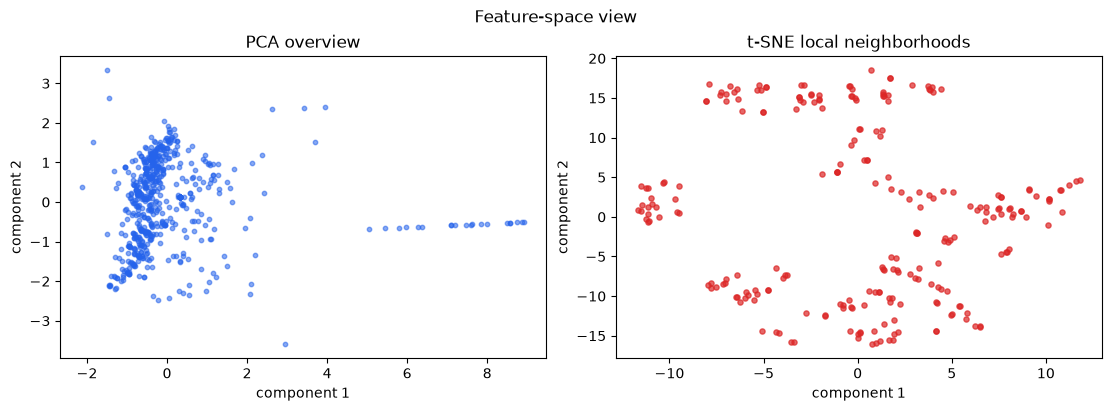

In [12]:
numeric = feature_frame.select(feature_names).to_numpy()
try:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler

    scaled = StandardScaler().fit_transform(numeric)
    pca = PCA(n_components=2, random_state=42).fit_transform(scaled)
    sample_n = min(240, len(scaled))
    perplexity = min(30, max(5, sample_n // 10))
    embedding = TSNE(
        n_components=2,
        random_state=42,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
        max_iter=350,
    ).fit_transform(scaled[:sample_n])
    assert embedding.shape == (sample_n, 2)
except ImportError:
    pca = None
    embedding = numeric[: min(240, len(numeric))]

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    if pca is not None:
        axes[0].scatter(pca[:, 0], pca[:, 1], s=10, alpha=0.55, color="#2563eb")
        axes[0].set_title("PCA overview")
        axes[0].set_xlabel("component 1")
        axes[0].set_ylabel("component 2")
    else:
        axes[0].axis("off")
        axes[0].text(0.5, 0.5, "PCA unavailable\ninstall scikit-learn", ha="center", va="center")
    axes[1].scatter(embedding[:, 0], embedding[:, 1], s=14, alpha=0.7, color="#dc2626")
    axes[1].set_title("t-SNE local neighborhoods")
    axes[1].set_xlabel("component 1")
    axes[1].set_ylabel("component 2")
    fig.suptitle("Feature-space view")
    plt.show()
except ImportError:
    print("Install matplotlib to render the feature-space plot.")

In [13]:
reference_rows = rows[: len(rows) // 2]
comparison_rows = rows[len(rows) // 2 :]
drift = compare_windows(
    reference_rows,
    comparison_rows,
    DriftConfig(reference_name="train-window", comparison_name="replay-window", minimum_samples=10),
)
print("Drift comparison")
print(f"  metrics: {len(drift.metrics)}")
print(f"  alerts: {len(drift.alerts)}")
print(f"  fingerprint: {drift.fingerprint[:12]}...")
assert drift.reference_count + drift.comparison_count == len(rows)

Drift comparison
  metrics: 137
  alerts: 63
  fingerprint: 37ce0d2b6f00...


In [14]:
matured_rows = [row for row in rows if row["label"] is not None]
prediction_scores = {prediction.event_id: prediction.fraud_score for prediction in predictions}
reference_rows = [row for row in matured_rows if row["split"] == "train"]
comparison_rows = [row for row in matured_rows if row["split"] == "test"]


def performance_values(candidate_rows):
    labels = [int(row["label"] == "FRAUD") for row in candidate_rows]
    scores = [prediction_scores[row["event_id"]] for row in candidate_rows]
    row_ids = [row["dataset_row_id"] for row in candidate_rows]
    return {
        "pr_auc": pr_auc(labels, scores, row_ids),
        "roc_auc": auc(labels, scores, row_ids),
    }


reference_values = performance_values(reference_rows)
comparison_values = performance_values(comparison_rows)
if (
    len(matured_rows) >= 20
    and all(value is not None for value in reference_values.values())
    and all(value is not None for value in comparison_values.values())
):
    performance = compare_performance(
        reference_values,
        comparison_values,
        config=DriftConfig(reference_name="train", comparison_name="test", minimum_samples=10),
        label_policy="exclude_unresolved",
    )
    print("Performance comparison")
    print(f"  metrics: {len(performance)}")
    print(f"  alerts: {sum(metric.alerted for metric in performance)}")
else:
    print("Performance comparison deferred")
    print(f"  matured rows: {len(matured_rows):,}")
    print("  reason: each window needs both FRAUD and LEGITIMATE matured labels")
    print("  policy: exclude_unresolved")

Performance comparison deferred
  matured rows: 78
  reason: each window needs both FRAUD and LEGITIMATE matured labels
  policy: exclude_unresolved


In [15]:
analysis_manifest = {
    "run_id": data.run_id,
    "feature_names": feature_names,
    "tsne_points": int(embedding.shape[0]),
    "drift_fingerprint": drift.fingerprint,
    "label_policy": "exclude_unresolved",
}
analysis_manifest["fingerprint"] = sha256_json(analysis_manifest)
print("Analysis artifact")
print(f"  Run ID: {analysis_manifest['run_id']}")
print(f"  Features: {len(analysis_manifest['feature_names'])}")
print(f"  t-SNE points: {analysis_manifest['tsne_points']:,}")
print(f"  Drift fingerprint: {analysis_manifest['drift_fingerprint'][:12]}...")
print(f"  Manifest fingerprint: {analysis_manifest['fingerprint'][:12]}...")
print(f"  Label policy: {analysis_manifest['label_policy']}")
assert analysis_manifest["fingerprint"] == sha256_json(
    {k: v for k, v in analysis_manifest.items() if k != "fingerprint"}
)

Analysis artifact
  Run ID: RUN-3c8a07d6ac6d0773
  Features: 6
  t-SNE points: 240
  Drift fingerprint: 37ce0d2b6f00...
  Manifest fingerprint: 8a457ce5b190...
  Label policy: exclude_unresolved


## Verification and next step

Re-run the offline cells from a clean checkout and compare the printed fingerprints. For service-backed publication, continue with the relevant integration runbook after this notebook; do not treat synthetic metrics as a deployment SLO.
